# Measurement Operators Comparison

This notebook compares the three measurement operators:
1. **DirectFourier1D**: Direct Fourier transform for non-uniform λ²
2. **GriddedFFT1D**: FFT-based for uniform λ² grids
3. **NUFFT1D**: Non-uniform FFT with Kaiser interpolation

All three should produce consistent results for point source detection.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from csromer.simulation import FaradayThinSource
from csromer.reconstruction import Parameter
from csromer.transformers.measurement_operator import (
    DirectFourier1D,
    GriddedFFT1D,
    NUFFT1D,
)
from csromer.transformers.gridding import Gridding
from csromer.utils.array_utils import asnumpy

plt.rcParams['figure.figsize'] = (14, 8)
%matplotlib inline

## 1. Create Test Source

Simulate a point source at different Faraday depths.

In [2]:
# Uniform frequency grid
nu = np.linspace(1.0e9, 1.5e9, 128)

# Test with different Faraday depths
phi_test_values = [0.0, 50.0, 100.0, -50.0]

print("Testing measurement operators with point sources at:")
for phi_test in phi_test_values:
    print(f"  φ = {phi_test:+.1f} rad/m²")

Testing measurement operators with point sources at:
  φ = +0.0 rad/m²
  φ = +50.0 rad/m²
  φ = +100.0 rad/m²
  φ = -50.0 rad/m²


## 2. Compare Operators for Each Faraday Depth

**Important:** All three operators use the `dirty_spectrum()` method which automatically:
- Weights the data: `w * p` (or `(w/s) * p` if spectral index correction is applied)
- Normalizes by `sum(w)` (or `sum(w/s)`) to get `w*p/sum(w)` before passing to the adjoint operator
- This ensures consistent units and normalization across all measurement operators

The dirty spectrum is computed as: `A^H(weighted_data)` where `weighted_data = (w*p)/sum(w)`.

In [3]:
results = {}

for phi_test in phi_test_values:
    # Create source
    source = FaradayThinSource(
        nu=nu,
        s_nu=0.1,
        phi_gal=phi_test,
        spectral_idx=0.0,
    )
    source.simulate()
    source.apply_noise(0.005, random_state=np.random.RandomState(42))
    
    # Ensure weights are set (should be set automatically, but verify)
    if source.w is None:
        # Set uniform weights if not set
        source.w = np.ones(len(source.data), dtype=np.float32)
    
    # Set up phi grid first (formulas + oversampling), then Nyquist gives d_lambda²
    param = Parameter()
    param.calculate_cellsize(dataset=source, oversampling=4.0, verbose=False)
    # Nyquist for GriddedFFT1D: d_phi * d_lambda² = π/N  =>  d_lambda² = π/(N * d_phi)
    d_lambda2 = np.pi / (param.n * param.cellsize)
    
    # Test DirectFourier1D (works with non-uniform λ²)
    op_dft = DirectFourier1D(dataset=source, parameter=param)
    fd_dirty_dft = op_dft.dirty_spectrum(source.data)
    fd_dirty_dft_np = np.asarray(asnumpy(fd_dirty_dft))
    peak_idx_dft = np.argmax(np.abs(fd_dirty_dft_np))
    peak_phi_dft = param.phi[peak_idx_dft]
    
    # Test GriddedFFT1D: same phi grid (length & resolution) as other methods; grid λ² with Nyquist d_lambda² and n=param.n
    gridding = Gridding(dataset=source, d_lambda2=d_lambda2, n=param.n)
    gridded_source = gridding.run()
    if gridded_source.w is None:
        raise ValueError("Gridded dataset missing weights!")
    gridded_source.l2_ref = 0.0
    
    op_fft = GriddedFFT1D(dataset=gridded_source, parameter=param)
    fd_dirty_fft = op_fft.dirty_spectrum(gridded_source.data)
    fd_dirty_fft_np = np.asarray(asnumpy(fd_dirty_fft))
    peak_idx_fft = np.argmax(np.abs(fd_dirty_fft_np))
    peak_phi_fft = param.phi[peak_idx_fft]
    
    # Test NUFFT1D (works with non-uniform λ²)
    # dirty_spectrum handles weighting: w*p/sum(w) before adjoint
    op_nufft = NUFFT1D(dataset=source, parameter=param)
    fd_dirty_nufft = op_nufft.dirty_spectrum(source.data)
    fd_dirty_nufft_np = np.asarray(asnumpy(fd_dirty_nufft))
    peak_idx_nufft = np.argmax(np.abs(fd_dirty_nufft_np))
    peak_phi_nufft = param.phi[peak_idx_nufft]
    
    # Check normalization consistency (peak amplitudes should be similar)
    peak_amp_dft = np.max(np.abs(fd_dirty_dft_np))
    peak_amp_fft = np.max(np.abs(fd_dirty_fft_np))
    peak_amp_nufft = np.max(np.abs(fd_dirty_nufft_np))
    
    results[phi_test] = {
        'dft': {'peak': peak_phi_dft, 'spectrum': fd_dirty_dft_np, 'phi': param.phi, 'peak_amp': peak_amp_dft},
        'fft': {'peak': peak_phi_fft, 'spectrum': fd_dirty_fft_np, 'phi': param.phi, 'peak_amp': peak_amp_fft},
        'nufft': {'peak': peak_phi_nufft, 'spectrum': fd_dirty_nufft_np, 'phi': param.phi, 'peak_amp': peak_amp_nufft},
    }
    
    print(f"\nφ = {phi_test:+.1f} rad/m²:")
    print(f"  DirectFourier1D peak: {peak_phi_dft:+.2f} rad/m² (error: {abs(peak_phi_dft - phi_test):.2f}, amp: {peak_amp_dft:.6f})")
    print(f"  GriddedFFT1D peak:    {peak_phi_fft:+.2f} rad/m² (error: {abs(peak_phi_fft - phi_test):.2f}, amp: {peak_amp_fft:.6f})")
    print(f"  NUFFT1D peak:         {peak_phi_nufft:+.2f} rad/m² (error: {abs(peak_phi_nufft - phi_test):.2f}, amp: {peak_amp_nufft:.6f})")
    
    # Warn if amplitudes differ significantly (indicates normalization issue)
    amp_ratios = [peak_amp_fft/peak_amp_dft if peak_amp_dft > 0 else 0, 
                  peak_amp_nufft/peak_amp_dft if peak_amp_dft > 0 else 0]
    if any(r > 0 and (r < 0.5 or r > 2.0) for r in amp_ratios):
        print(f"  ⚠ Warning: Peak amplitudes differ significantly - check normalization!")


φ = +0.0 rad/m²:
  DirectFourier1D peak: +0.00 rad/m² (error: 0.00, amp: 0.099673)
  GriddedFFT1D peak:    +0.00 rad/m² (error: 0.00, amp: 0.099649)
  NUFFT1D peak:         +0.00 rad/m² (error: 0.00, amp: 0.099673)

φ = +50.0 rad/m²:
  DirectFourier1D peak: +50.42 rad/m² (error: 0.42, amp: 0.099796)
  GriddedFFT1D peak:    +50.42 rad/m² (error: 0.42, amp: 0.099541)
  NUFFT1D peak:         +50.42 rad/m² (error: 0.42, amp: 0.099652)

φ = +100.0 rad/m²:
  DirectFourier1D peak: +100.83 rad/m² (error: 0.83, amp: 0.100171)
  GriddedFFT1D peak:    +100.83 rad/m² (error: 0.83, amp: 0.099184)
  NUFFT1D peak:         +100.83 rad/m² (error: 0.83, amp: 0.099597)

φ = -50.0 rad/m²:
  DirectFourier1D peak: -50.42 rad/m² (error: 0.42, amp: 0.099956)
  GriddedFFT1D peak:    -50.42 rad/m² (error: 0.42, amp: 0.099729)
  NUFFT1D peak:         -50.42 rad/m² (error: 0.42, amp: 0.099812)


## 3. Visualize Comparison

Plot the dirty spectra from all three operators.

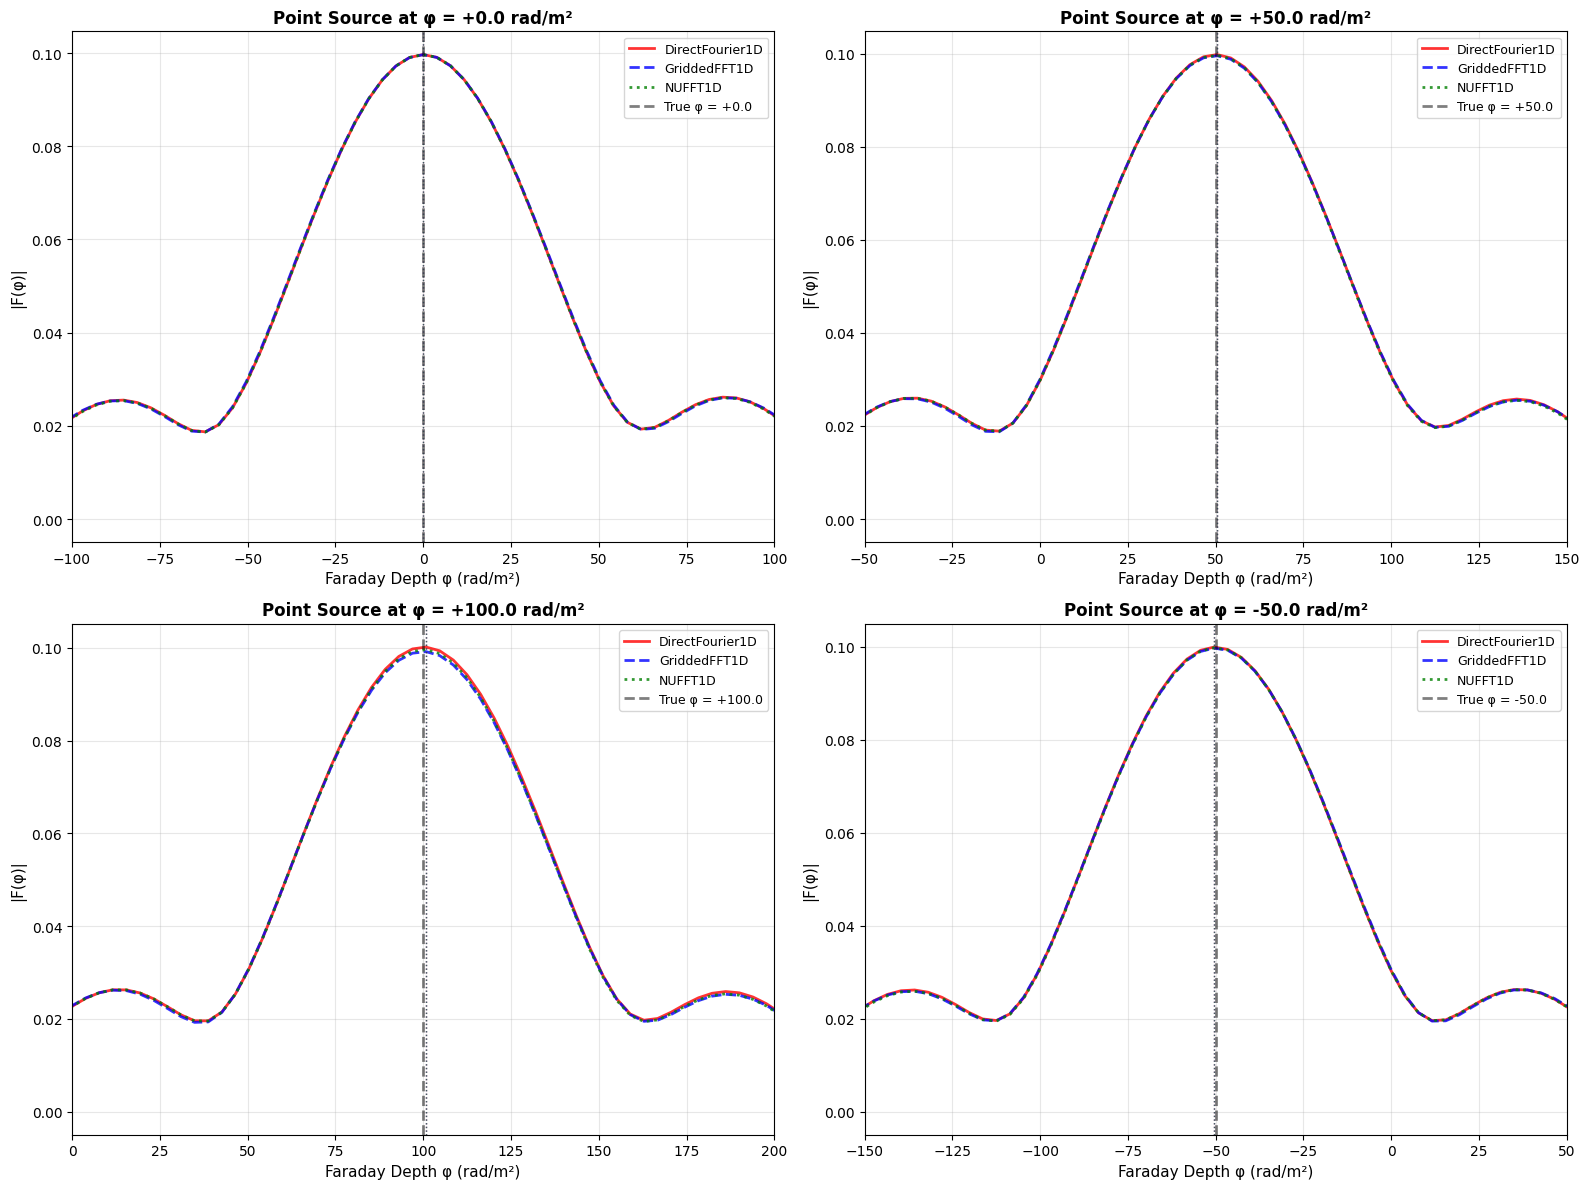


Summary:
All three operators should produce consistent peak locations.
DirectFourier1D: Most accurate, works with any λ² sampling
GriddedFFT1D: Fastest, requires uniform λ² grid
NUFFT1D: Fast with Kaiser interpolation, works with non-uniform λ²


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, phi_test in enumerate(phi_test_values):
    ax = axes[idx]
    res = results[phi_test]
    
    # Plot all three operators
    ax.plot(res['dft']['phi'], np.abs(res['dft']['spectrum']), 
            'r-', linewidth=2, label='DirectFourier1D', alpha=0.8)
    ax.plot(res['fft']['phi'], np.abs(res['fft']['spectrum']), 
            'b--', linewidth=2, label='GriddedFFT1D', alpha=0.8)
    ax.plot(res['nufft']['phi'], np.abs(res['nufft']['spectrum']), 
            'g:', linewidth=2, label='NUFFT1D', alpha=0.8)
    
    # Mark true and detected peaks
    ax.axvline(phi_test, color='k', linestyle='--', linewidth=2, 
               label=f'True φ = {phi_test:+.1f}', alpha=0.5)
    ax.axvline(res['dft']['peak'], color='r', linestyle=':', linewidth=1, alpha=0.5)
    ax.axvline(res['fft']['peak'], color='b', linestyle=':', linewidth=1, alpha=0.5)
    ax.axvline(res['nufft']['peak'], color='g', linestyle=':', linewidth=1, alpha=0.5)
    
    ax.set_xlabel('Faraday Depth φ (rad/m²)', fontsize=11)
    ax.set_ylabel('|F(φ)|', fontsize=11)
    ax.set_title(f'Point Source at φ = {phi_test:+.1f} rad/m²', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9, loc='best')
    ax.grid(True, alpha=0.3)
    
    # Zoom to peak region
    peak_range = 100
    ax.set_xlim(phi_test - peak_range, phi_test + peak_range)

plt.tight_layout()
plt.show()

print("\nSummary:")
print("All three operators should produce consistent peak locations.")
print("DirectFourier1D: Most accurate, works with any λ² sampling")
print("GriddedFFT1D: Fastest, requires uniform λ² grid")
print("NUFFT1D: Fast with Kaiser interpolation, works with non-uniform λ²")